<a href="https://colab.research.google.com/github/AndresMontesDeOca/AnalisisDatos2/blob/main/Entregas/Actividad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# 1. Cargar el dataset de UCI
communities_and_crime = fetch_ucirepo(id=183)
X = communities_and_crime.data.features
y = communities_and_crime.data.targets

# 2. Combinar X e y en un solo DataFrame
data = pd.concat([X, y], axis=1)

# Reemplazar los '?' por NaN reales de numpy
data = data.replace('?', np.nan)

# Mostrar el resumen del DataFrame limpio
print(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), object(26)
memory usage: 1.9+ MB
None


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


<Figure size 1000x600 with 0 Axes>

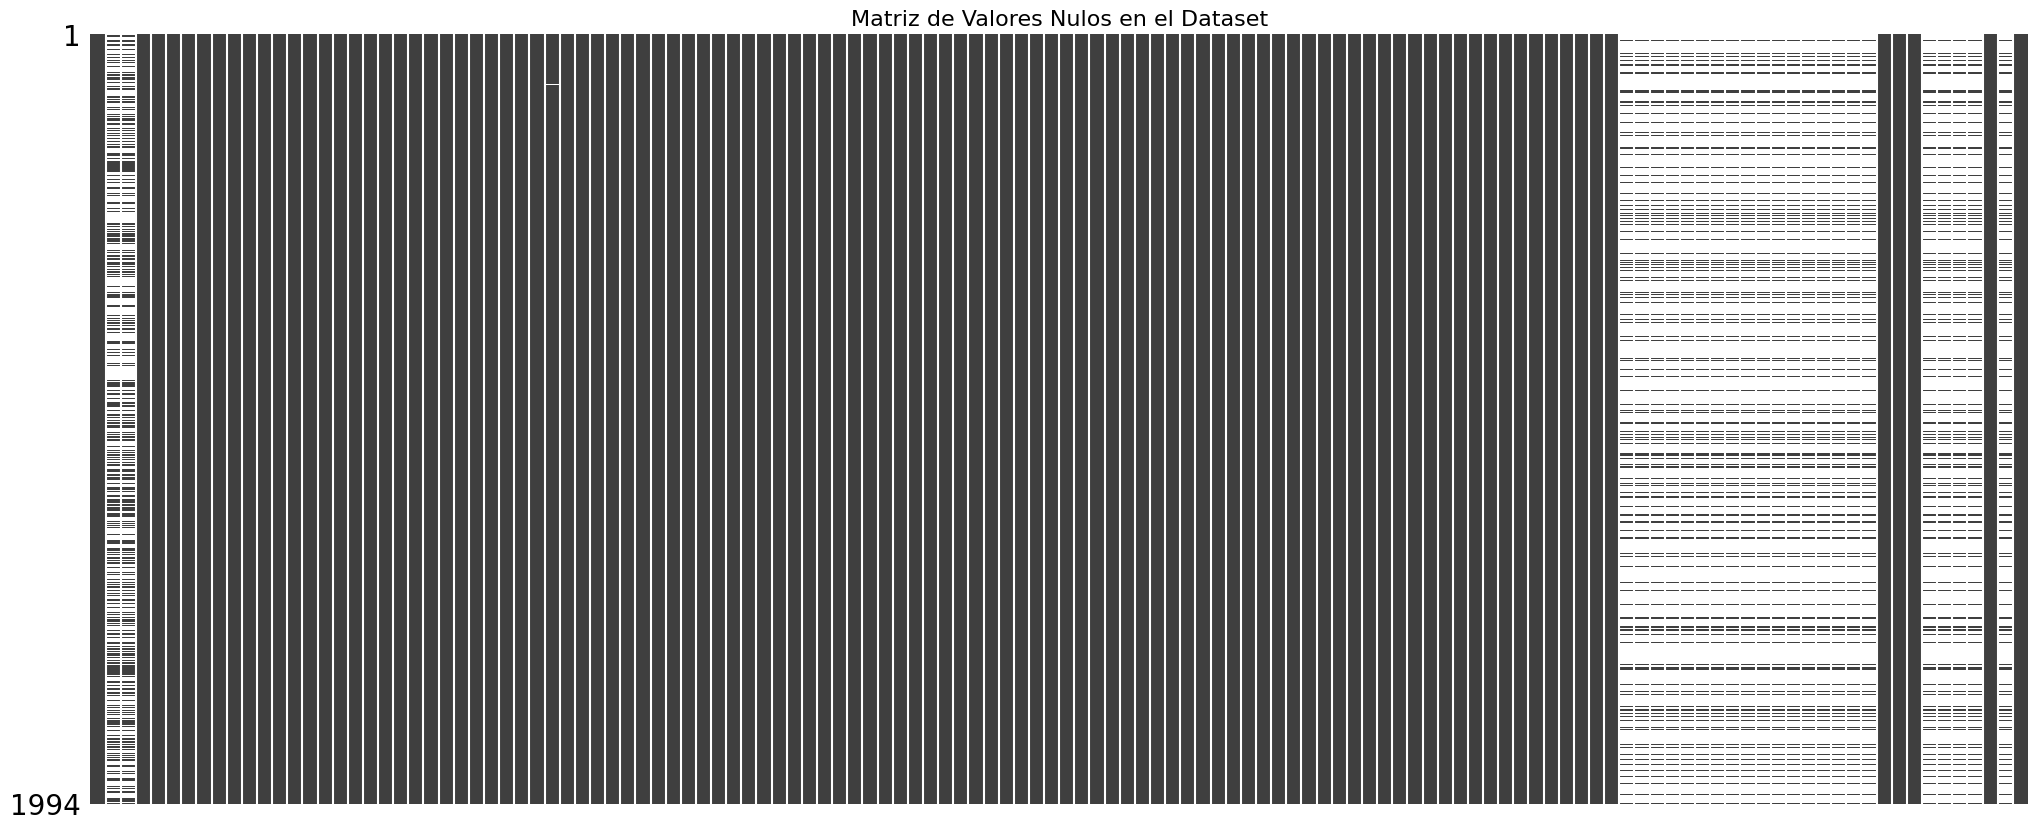

In [12]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualizar la matriz de valores nulos
plt.figure(figsize=(10, 6))
msno.matrix(data, sparkline=False)
plt.title("Matriz de Valores Nulos en el Dataset", fontsize=16)
plt.show()

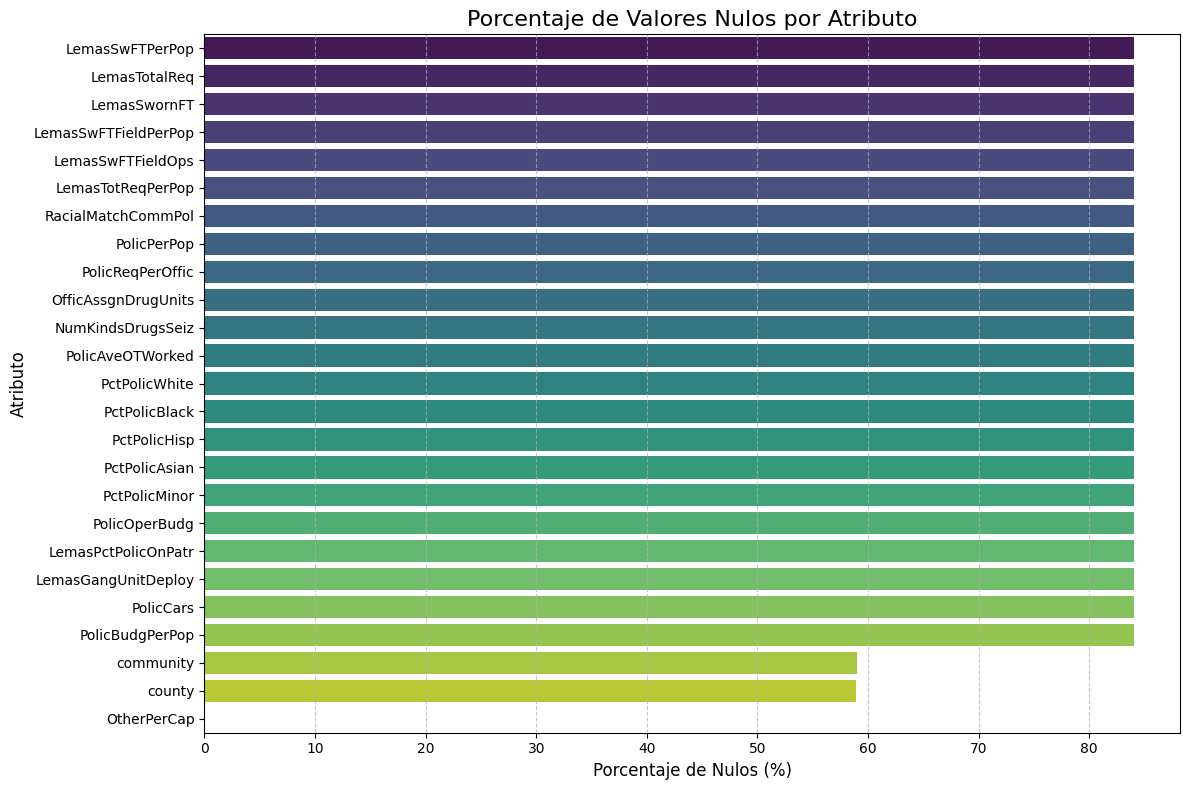

In [13]:
import seaborn as sns

# Calcular el porcentaje de nulos
null_percentages = (data.isnull().sum() / len(data)) * 100

# Filtrar solo las columnas con nulos y ordenarlas
null_cols = null_percentages[null_percentages > 0].sort_values(ascending=False).reset_index()
null_cols.columns = ['Atributo', 'Porcentaje_Nulos']

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x='Porcentaje_Nulos', y='Atributo', data=null_cols, palette='viridis', hue='Atributo', legend=False)

# Configurar etiquetas y títulos
plt.title('Porcentaje de Valores Nulos por Atributo', fontsize=16)
plt.xlabel('Porcentaje de Nulos (%)', fontsize=12)
plt.ylabel('Atributo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
print(f"Total de filas en el dataset: {len(data)}")
print(f"Valores únicos de 'state': {data['state'].nunique()}")
print(f"Valores únicos de 'county': {data['county'].nunique()} (excluyendo NaN)")
print(f"Valores únicos de 'community': {data['community'].nunique()} (excluyendo NaN)")
print(f"Valores únicos de 'communityname': {data['communityname'].nunique()}")

# Verificar combinaciones de ubicación para ver si identifican filas únicas
comb_state_county = data.dropna(subset=['county']).groupby(['state', 'county']).size()
print(f"\nCombinaciones únicas de ['state', 'county']: {len(comb_state_county)}")

comb_completa = data.dropna(subset=['county', 'community']).groupby(['state', 'county', 'community']).size()
print(f"Combinaciones únicas de ['state', 'county', 'community']: {len(comb_completa)}")

Total de filas en el dataset: 1994
Valores únicos de 'state': 46
Valores únicos de 'county': 108 (excluyendo NaN)
Valores únicos de 'community': 799 (excluyendo NaN)
Valores únicos de 'communityname': 1828

Combinaciones únicas de ['state', 'county']: 247
Combinaciones únicas de ['state', 'county', 'community']: 817


In [15]:
# Filtrar las filas donde state, county y community tienen el mismo valor
# Primero convertimos a float o string para asegurar una comparación correcta si difieren en tipos
coincidencias = data[
    (data['state'].astype(str) == data['county'].astype(str)) &
    (data['county'].astype(str) == data['community'].astype(str))
]

print(f"Número de filas donde 'state' == 'county' == 'community': {len(coincidencias)}")
if len(coincidencias) > 0:
    display(coincidencias[['state', 'county', 'community', 'communityname']])

Número de filas donde 'state' == 'county' == 'community': 0


In [16]:
# Contar valores nulos específicos para state, county y community
nulos_geograficos = data[['state', 'county', 'community']].isnull().sum()

for col, nulos in nulos_geograficos.items():
    total = len(data)
    pct = (nulos / total) * 100
    print(f"Columna '{col}': {nulos} valores nulos de {total} ({pct:.2f}%)")

Columna 'state': 0 valores nulos de 1994 (0.00%)
Columna 'county': 1174 valores nulos de 1994 (58.88%)
Columna 'community': 1177 valores nulos de 1994 (59.03%)


In [ ]:
# Verificar nulos en 'communityname'
nulos_name = data['communityname'].isnull().sum()

# Verificar duplicados en 'communityname'
total_filas = len(data)
valores_unicos = data['communityname'].nunique()
repetidos = total_filas - valores_unicos

print(f"Columna 'communityname':")
print(f"- Valores nulos: {nulos_name}")
print(f"- Nombres únicos: {valores_unicos} de {total_filas} filas")
print(f"- Nombres repetidos (coincidencias de nombre): {repetidos}")

# Mostrar algunos ejemplos de nombres que se repiten para entender por qué ocurre
si_repetidos = data[data.duplicated(subset=['communityname'], keep=False)]
si_repetidos_grouped = si_repetidos.groupby('communityname').size().reset_index(name='Frecuencia').sort_values(by='Frecuencia', ascending=False)
print("\nEjemplos de nombres de comunidades repetidos y cuántas veces aparecen:")
display(si_repetidos_grouped.head(10))